In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [1]:
from x_retrieval_library import compute_gain_value, GainValueDisplay, AkMatrixDisplay

## Gain matrices

In [2]:
g = GainValueDisplay()
g.display

Questions to consider:

1. Why does the gain increase with prior uncertainty ($\sigma_a$)?
2. Why does the gain decrease with measurement uncertainty ($\sigma_\epsilon$)?
3. Fix the $y$ axis range and vary $k$ from near 0 to $\sim$ 5, or use the `compute_gain_value` function to plot $g$ as a function of $k$ for different $\sigma_a$ and $\sigma_\epsilon$ values.
    1. How does $g$ depend on $k$ when $k$ is small? Why does $\partial g/\partial k$ have that sign?
    2. How does $g$ depend on $k$ when $k$ is larger? Why does $\partial g/\partial k$ have _that_ sign?

## Averaging kernel

In [3]:
a = AkMatrixDisplay()
a.display

Questions to consider:

1. Change the variance of one of the prior terms. How does the AK respond and why?
2. Reset, then change the covariance of the prior terms. How does the AK respond and why might that be?
3. Reset, then change the variance of one of the measurement terms. How does the AK respond and why?
4. Reset, then increase the $y_{12}$ covariance. How do the diagonal terms of the AK change, and why might that be? What about if you increase the $y_{23}$ covariance?
5. Reset, then increase the $y_{13}$ covariance? What happens to the AK matrix?

## Answers

### Gain matrix

_Why does the gain increase with prior uncertainty ($\sigma_a$)?_

> Increasing prior uncertainty means the prior is a weaker constraint, so the solution has more flexibility to move away from the prior

_Why does the gain decrease with measurement uncertainty ($\sigma_\epsilon$)?_

> Increasing measurement uncertainty means that your measurement has more noise, essentially. That means that we should put less weight on the measurement compared to the prior, so the measurement has less impact on the solution.

_Fix the $y$ axis range and vary $k$ from near 0 to $\sim$ 5, or use the `compute_gain_value` function to plot $g$ as a function of $k$ for different $\sigma_a$ and $\sigma_\epsilon$ values._

> If you plotted $g$ vs $k$, you should see the following:

Text(0, 0.5, '$g$')

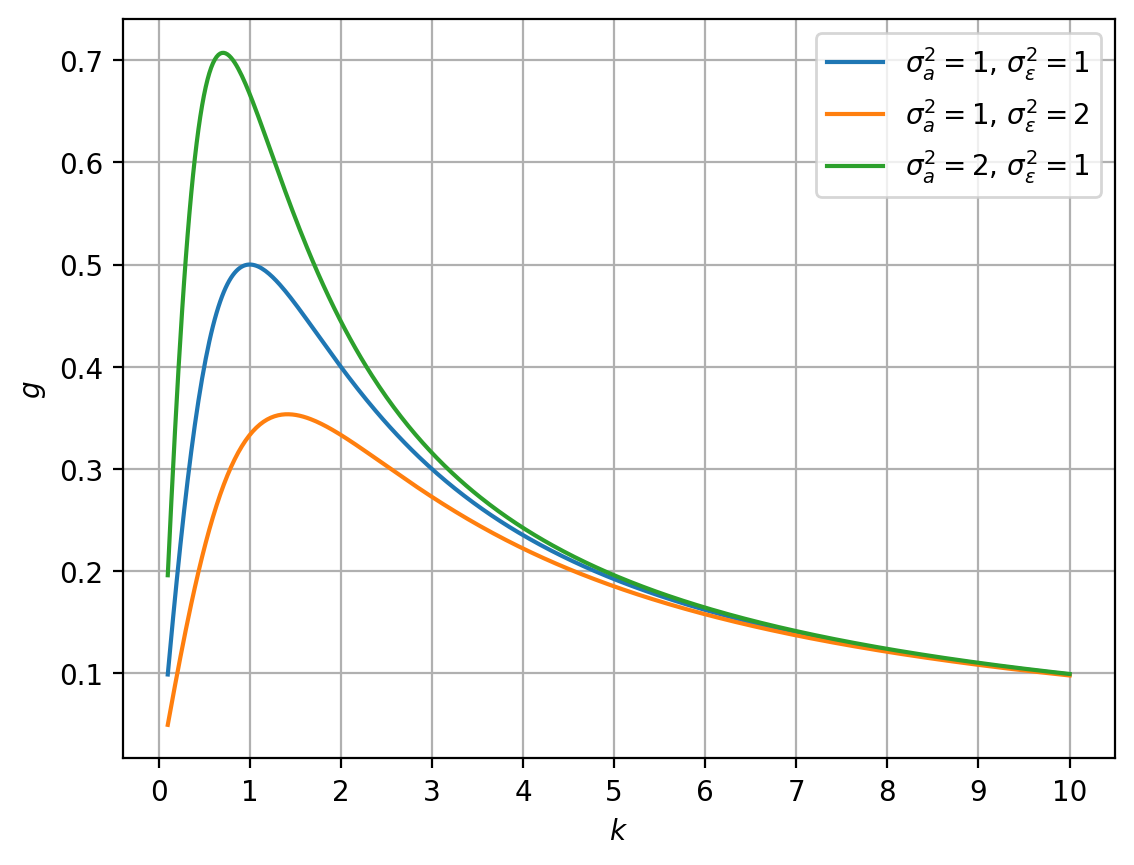

In [38]:
plt.plot(np.linspace(0.1, 10, 500), compute_gain_value(np.linspace(0.1, 10., 500), 1.0, 1.0), label=r'$\sigma_a^2=1$, $\sigma_\epsilon^2=1$')
plt.plot(np.linspace(0.1, 10, 500), compute_gain_value(np.linspace(0.1, 10., 500), 1.0, 2.0), label=r'$\sigma_a^2=1$, $\sigma_\epsilon^2=2$')
plt.plot(np.linspace(0.1, 10, 500), compute_gain_value(np.linspace(0.1, 10., 500), 2.0, 1.0), label=r'$\sigma_a^2=2$, $\sigma_\epsilon^2=1$')
plt.xticks(np.arange(0, 10.1))
plt.grid()
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$g$')

_How does $g$ depend on $k$ when $k$ is small? Why does $\partial g/\partial k$ have that sign?_

> From the plot, when $k$ is small, $\partial g / \partial k > 0$. Why?
> 
> Remember the expression for $\mathbf{G}$ is:
> $$\mathbf{G} = \left( \mathbf{K}^T \mathbf{S}_\epsilon^{-1} \mathbf{K} + \mathbf{S}_a^{-1} \right)^{-1} \mathbf{K}^T \mathbf{S}_\epsilon^{-1}$$
> or in scalar form:
> $$g = \frac{k / \sigma_\epsilon^{2}}{k^2 / \sigma_\epsilon^{2} + 1/\sigma_a^{2}}$$
> When $k^2/\sigma_\epsilon^2 \ll 1/\sigma_a^2$, this reduces to $(k / \sigma_\epsilon^2) / (1/\sigma_a^2)$ and is linear in $k$. This says that when $k \approx 0$, the measurement ($y$) does not vary strongly with the state ($x$), so the measurement cannot give much information about the solution ($\hat{x}$). As $k$ increases, the information available from the measurement does too.

_How does $g$ depend on $k$ when $k$ is larger? Why does $\partial g/\partial k$ have **that** sign?_

> Now the sign flips: $\partial g / \partial k < 0$.
> This seems counterintuitive at first; shouldn't greater sensitivity of the measurement to the state make the solution more sensitive _to_ the measurement?
> Again, it's helpful to consider the limiting case, now $k^2/\sigma_\epsilon^2 \gg 1/\sigma_a^2$.
> This means that $g$ can be reduced to $(k/\sigma_\epsilon^2) / (k^2 / \sigma_\epsilon^2) = 1 / k$.
>
> Does this look familar?
> Remember the calibration curve example from lecture. If $y = mx + b$, then $\hat{x} = (y - b)/m$, or $\hat{x} \propto 1 / m$.
> Since $m$ (our calibration slope) is like $k$, this limiting case of $g$ is saying that our gain converges to the "ideal" inverse of the Jacobian.

### Averaging Kernel

_Increase the variance of one of the prior terms. How does the AK respond and why?_

> You should see the AK increase for the corresponding diagonal element, e.g. if you increased $x_{a_1}$'s variance, then the $x_1$/$\hat{x}_1$ AK element increases. Similar to what we saw with the gain matrix, as we loosen the prior constraint, our solution can respond more strongly to the true state that it corresponds to.

_Reset, then increase the covariance of the prior terms. How does the AK respond and why might that be?_

> You should see that both diagonal elements of the AK increase. Why is more complicated, but basically by imposing correlation between the state elements, we're reducing the number of unknowns, so the retrieval can apply more of the measurement information to effectively fewer unknowns.

_Reset, then increase the variance of one of the measurement terms. How does the AK respond and why?_

> If you did $y_1$ or $y_3$, you should see the AK increase for the other diagonal element, e.g. if you increased $y_1$'s variance, then the $x_2$/$\hat{x}_2$ AK element increases. The logic here is the opposite of the prior variance: our measurement is more uncertain, so we're able to get less information about the state element that impacts that measurement. If you did $y_2$, you'll see a small decrease in both AK diagonal elements. Since both terms of $\mathbf{x}$ weakly influence $y_2$ according to our $\mathbf{K}$, the reduced precision of $y_2$ weakly decreases our ability to constrain both state elements.

_Reset, then increase the $y_{12}$ covariance. How do the diagonal terms of the AK change, and why might that be? What about if you increase the $y_{23}$ covariance?_

> For $y_{12}$, you'll see the AK vary chaotically at first, then the $\partial \hat{x}_1/\partial x_1$ term decreases to look more like the off diagonals.
> I would interpret this intuitively as:
> - $x_1$ and $x_2$ both relate to $y_2$, so errors in $y_2$ affect both state elements
> - But errors in $y_2$ are correlated to errors in $y_1$, so since $x_1$ depends mainly on those two elements of $y$, it's more difficult to tell error in the measurement apart from real variance in $x_1$ - we've decreased independent information about $x_1$.
> - $x_2$ still has $y_3$, which has uncorrelated error with the other $y$ values, so it still has some inferrable information.
> The same logic flipped would apply to the $y_{23}$ covariance.

_Reset, then increase the $y_{13}$ covariance? What happens to the AK matrix?_

> Things get weird! Our diagonals go negative, and the off diagonals grow in magnitude.
> This is a point where intuition starts to break down, but really if you see an AK matrix with strongly positive off-diagonals and strongly negative diagonals, that's a warning sign that this solution is weird in a way that's likely to make it not so useful.